## NYC 311 Service Requests

In [24]:
# Import libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import requests

In [25]:
api_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"
limit = 50000
total_rows = 1_000_000   # how many you want

def fetch(offset):
    params = {"$limit": limit, "$offset": offset}
    r = requests.get(api_url, params=params)
    return r.json()

offsets = range(0, total_rows, limit)

with ThreadPoolExecutor(max_workers=10) as pool:
    results = list(pool.map(fetch, offsets))

rows = [row for batch in results for row in batch]

df = pd.DataFrame(rows)

In [ ]:
# # API Request 

# # create api request. Due to size of the dataset it has been limited to 400K rows
# api_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json?$limit=1000000"

# # https://data.cityofnewyork.us/resource/erm2-nwe9.json
# # api_url = "https://data.cityofnewyork.us/resource/76ig-c548.json"
# response = requests.get(api_url)

# # get response and turn data into a dataframe 
# if response.status_code == 200:
#     data = response.json()
#     # convert to DataFrame
#     data = pd.DataFrame(data)
#     print(data.head())

KeyboardInterrupt: 

In [27]:
df.shape


(1000000, 48)

In [28]:
# Review column names 
df.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'incident_zip', 'incident_address',
       'street_name', 'cross_street_1', 'cross_street_2', 'address_type',
       'city', 'facility_type', 'status', 'resolution_description',
       'resolution_action_updated_date', 'community_board', 'police_precinct',
       'borough', 'open_data_channel_type', 'park_facility_name',
       'park_borough', 'intersection_street_1', 'intersection_street_2',
       'council_district', 'x_coordinate_state_plane',
       'y_coordinate_state_plane', 'latitude', 'longitude', 'location',
       ':@computed_region_f5dn_yrer', ':@computed_region_yeji_bk3q',
       ':@computed_region_sbqj_enih', ':@computed_region_92fq_4b7q',
       'location_type', 'landmark', 'bbl', 'vehicle_type', 'descriptor_2',
       'taxi_pick_up_location', 'bridge_highway_name',
       'bridge_highway_segment', 'taxi_company_borough',
       'bridge_highway_direction', '

In [29]:
# Keep only needed columns
cols = [
    "created_date",
    "closed_date",
    "complaint_type",
    "borough",
    "agency"
]

df = df[cols]

In [30]:
# Convert datetime
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
df["closed_date"] = pd.to_datetime(df["closed_date"], errors="coerce")


In [31]:
df.isna().sum()

created_date          0
closed_date       98951
complaint_type        0
borough               0
agency                0
dtype: int64

In [32]:
# Drop rows without close date
df = df.dropna(subset=["closed_date"])

In [33]:
# Response time (hours)
df["response_hours"] = (
    df["closed_date"] - df["created_date"]
).dt.total_seconds() / 3600

In [34]:
# Remove negative/outliers
df = df[df["response_hours"] >= 0]
df = df[df["response_hours"] < 500]

In [35]:
# Time features
df["hour"] = df["created_date"].dt.hour
df["dayofweek"] = df["created_date"].dt.dayofweek
df["month"] = df["created_date"].dt.month

In [36]:
# Target: delayed = top 25% slowest
threshold = df["response_hours"].quantile(0.75)
df["delayed"] = (df["response_hours"] > threshold).astype(int)

print("Delay threshold:", threshold)

Delay threshold: 53.31666666666667


### Response Time Distribution

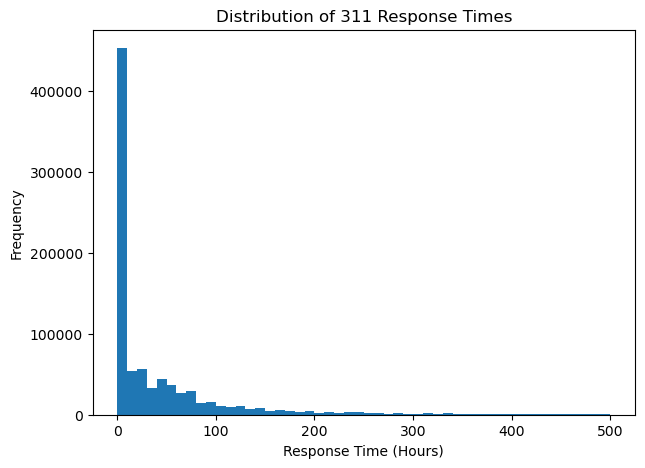

In [37]:
plt.figure(figsize=(7,5))
plt.hist(df["response_hours"], bins=50)
plt.xlabel("Response Time (Hours)")
plt.ylabel("Frequency")
plt.title("Distribution of 311 Response Times")
plt.show()

### Top Complaint Types

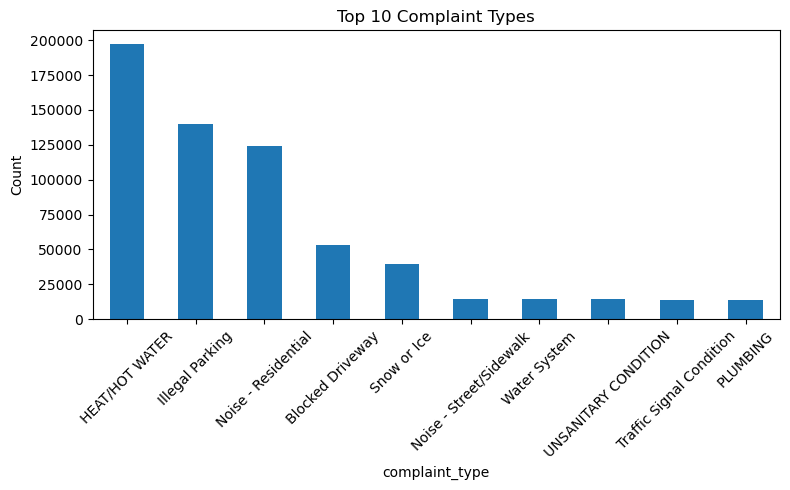

In [38]:
top_types = df["complaint_type"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_types.plot(kind="bar")
plt.ylabel("Count")
plt.title("Top 10 Complaint Types")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

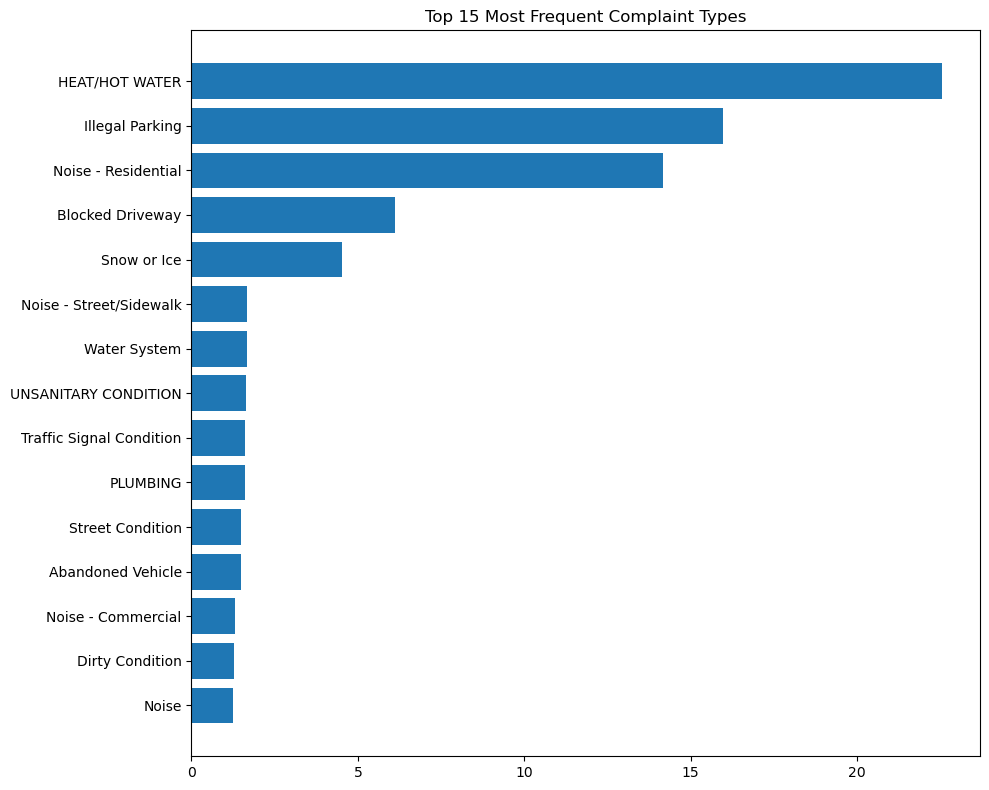

In [39]:
complaint_counts = df['complaint_type'].value_counts()
complaint_percentages = (complaint_counts / len(df) * 100).round(2)
# Horizontal bar chart 
plt.figure(figsize=(10, 8))
top_15 = complaint_percentages.head(15)
plt.barh(range(len(top_15)), top_15.values)
plt.yticks(range(len(top_15)), top_15.index)
plt.xlabel(None)
plt.ylabel(None)
plt.title('Top 15 Most Frequent Complaint Types')
plt.gca().invert_yaxis()  # Highest at top
plt.tight_layout()
plt.savefig('top_15_complaints_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

In [59]:
# Convert Created Date to datetime
df['created_date'] = pd.to_datetime(df['created_date'])

# Extract year
df['Year'] = df['created_date'].dt.year

# Count complaints by year
yearly_counts = df['Year'].value_counts().sort_index()

# Display the counts
print("Complaint Counts by Year:")
print("=" * 40)
for year, count in yearly_counts.items():
    print(f"{year}: {count:,} requests")

print(f"\nTotal requests: {yearly_counts.sum():,}")
print(f"Average per year: {yearly_counts.mean():,.0f}")

Complaint Counts by Year:
2025: 432,885 requests
2026: 441,601 requests

Total requests: 874,486
Average per year: 437,243


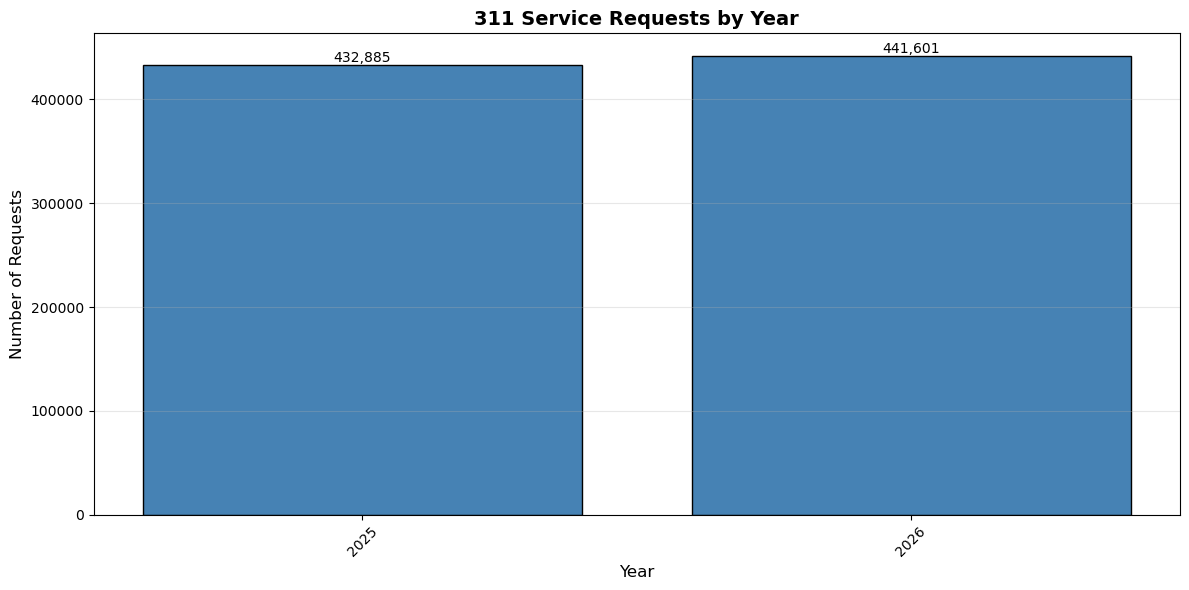

In [41]:
# Create a bar chart
plt.figure(figsize=(12, 6))
plt.bar(yearly_counts.index, yearly_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.title('311 Service Requests by Year', fontsize=14, fontweight='bold')
plt.xticks(yearly_counts.index, rotation=45)

# Add value labels on top of bars
for year, count in yearly_counts.items():
    plt.text(year, count, f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('complaints_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

### Complaints by Borough

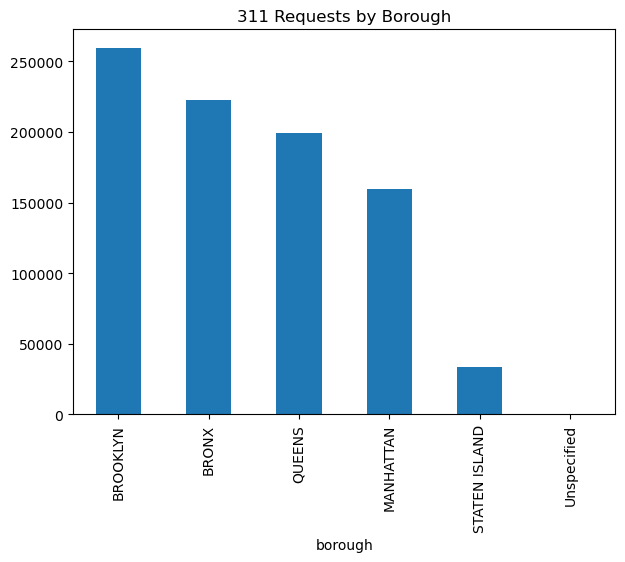

In [56]:
borough_counts = df["borough"].value_counts()

plt.figure(figsize=(7,5))
borough_counts.plot(kind="bar")
plt.ylabel(None)
plt.title("311 Requests by Borough")
plt.show()

### Requests by Hour of Day

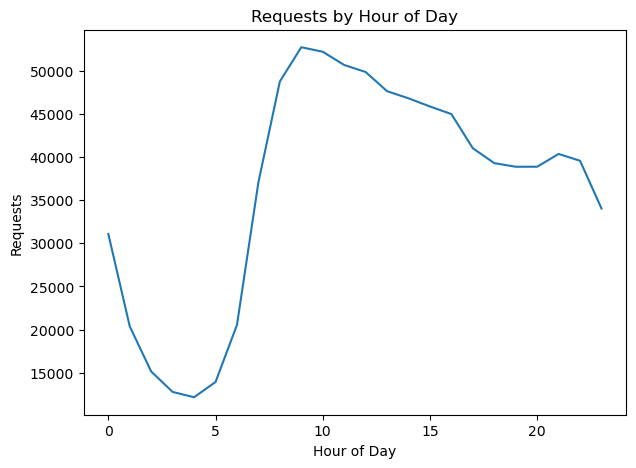

In [44]:
hourly = df.groupby("hour").size()

plt.figure(figsize=(7,5))
plt.plot(hourly.index, hourly.values)
plt.xlabel("Hour of Day")
plt.ylabel("Requests")
plt.title("Requests by Hour of Day")
plt.show()

### Avg Response Time by Borough

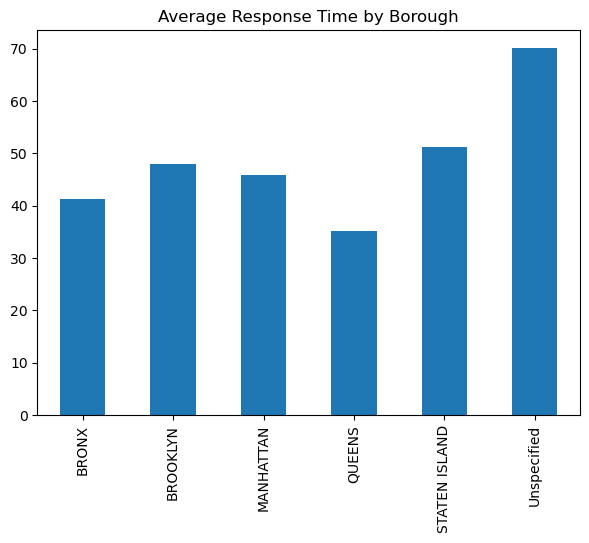

In [61]:
avg_response = df.groupby("borough")["response_hours"].mean()

plt.figure(figsize=(7,5))
avg_response.plot(kind="bar")
plt.ylabel(None)
plt.xlabel(None)
plt.title("Average Response Time by Borough")
plt.show()


In [46]:
# Prep features for ML
features = [
    "complaint_type",
    "borough",
    "agency",
    "hour",
    "dayofweek",
    "month"
]

target = "delayed"

X = df[features]
y = df[target]


In [47]:
# Train/Test/Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [48]:
cat_cols = ["complaint_type", "borough", "agency"]
num_cols = ["hour", "dayofweek", "month"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

In [49]:
# Logistic regression pipeline

log_model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['complaint_type', 'borough',
                                                   'agency']),
                                                 ('num', StandardScaler(),
                                                  ['hour', 'dayofweek',
                                                   'month'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [51]:
# Random Forest pipeline

rf_model = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        max_depth=15
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['complaint_type', 'borough',
                                                   'agency']),
                                                 ('num', StandardScaler(),
                                                  ['hour', 'dayofweek',
                                                   'month'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_jobs=-1, random_state=42))])

In [52]:
def evaluate(model, name):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))

evaluate(log_model, "Logistic Regression")
evaluate(rf_model, "Random Forest")


Logistic Regression
Accuracy: 0.7665335091825299
Precision: 0.5180978292619824
Recall: 0.9465282224865063
F1: 0.6696510919220957
ROC-AUC: 0.9007242889423982

Random Forest
Accuracy: 0.7669261204668644
Precision: 0.5180734661977335
Recall: 0.9702680450096057
F1: 0.6754768652676496
ROC-AUC: 0.9154689525879891


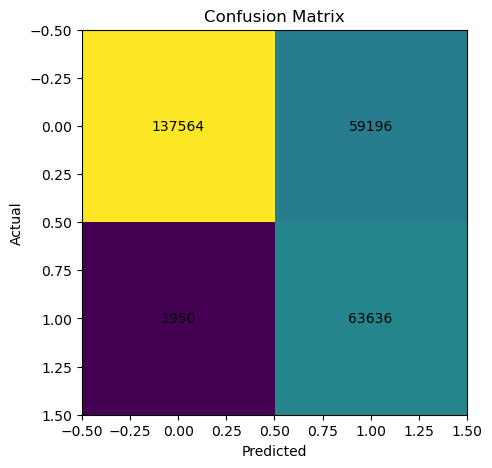

In [53]:
cm = confusion_matrix(y_test, rf_model.predict(X_test))

plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

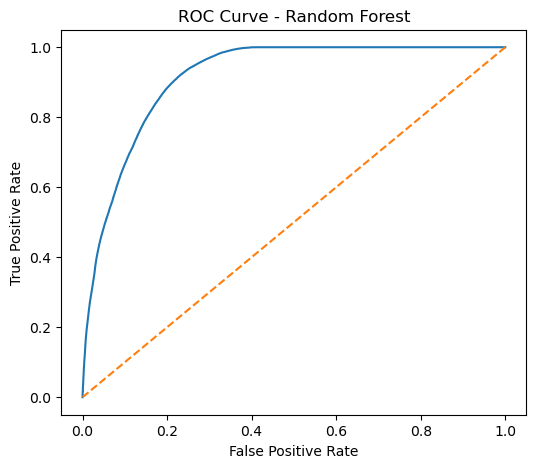

In [57]:
probs = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

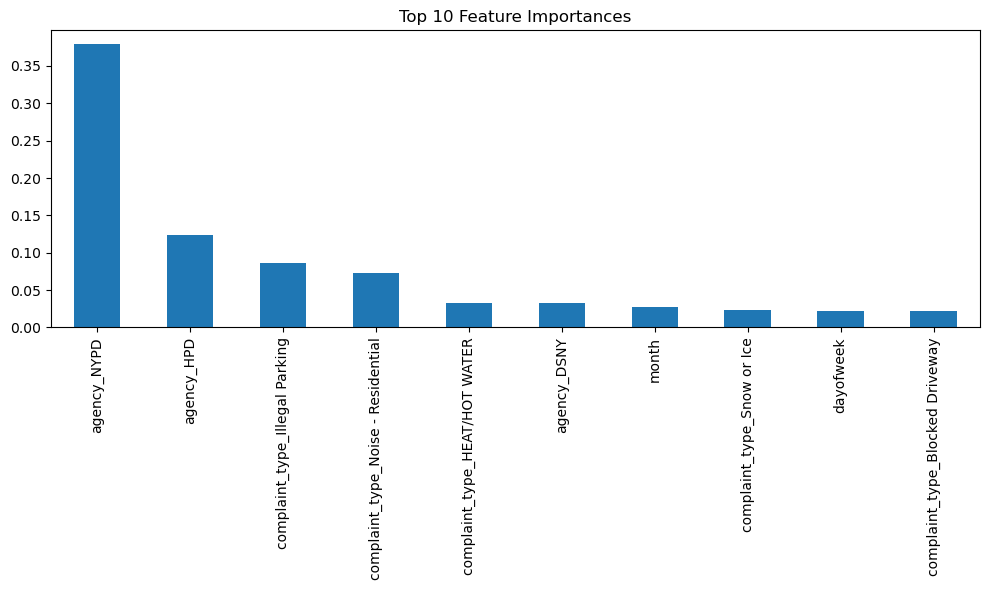

In [62]:
ohe = rf_model.named_steps["prep"].named_transformers_["cat"]
feature_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols

importances = rf_model.named_steps["clf"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:10]

plt.figure(figsize=(10,6))
feat_imp.plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.ylabel(None)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()